In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


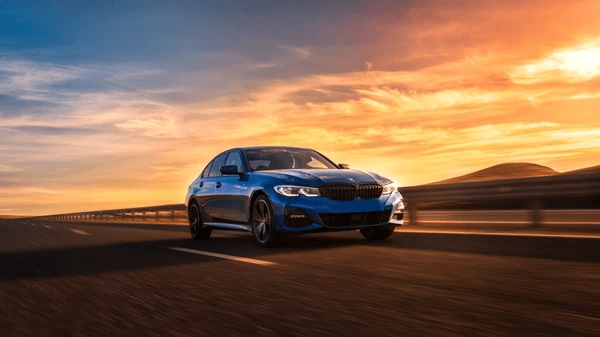

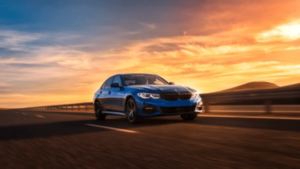

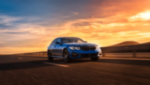

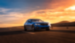

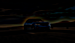

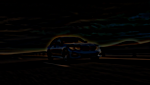

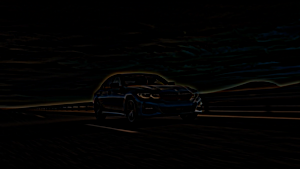

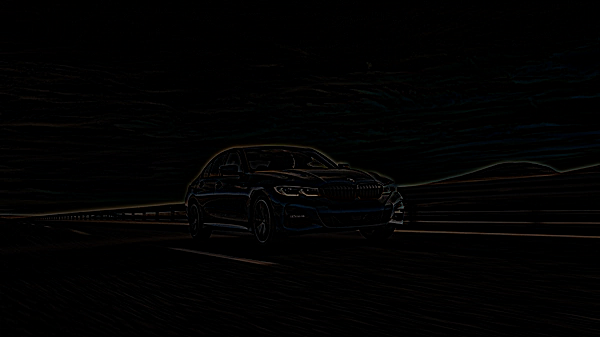

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the image
img = cv2.imread('/content/drive/MyDrive/opencv/bmw1.jpg')

gaussian_pyramid = [img]
for i in range(5):  # Create 5 levels (adjust as needed)
    img = cv2.pyrDown(img)
    gaussian_pyramid.append(img)
#Step 1: Initialize the list and add the last level of the Gaussian pyramid.
laplacian_pyramid = [gaussian_pyramid[-1]]
#Step 2: Generate subsequent levels by subtracting expanded versions.
for i in range(len(gaussian_pyramid) - 1, 0, -1):
    gaussian_expanded = cv2.pyrUp(gaussian_pyramid[i])
    # Ensure sizes match before subtraction, as pyrUp might not perfectly restore original size
    if gaussian_expanded.shape != gaussian_pyramid[i-1].shape:
        gaussian_expanded = cv2.resize(gaussian_expanded, (gaussian_pyramid[i-1].shape[1], gaussian_pyramid[i-1].shape[0]))

    laplacian = cv2.subtract(gaussian_pyramid[i-1], gaussian_expanded)
    laplacian_pyramid.append(laplacian)

# Display Gaussian pyramid levels
for i, level in enumerate(gaussian_pyramid):
    cv2_imshow(level)

# Display Laplacian pyramid levels
for i, level in enumerate(laplacian_pyramid):
    # For visualization, adjust contrast of Laplacian levels as they can have negative values
    display_laplacian = cv2.convertScaleAbs(level)
    cv2_imshow(display_laplacian)

# cv2.waitKey(0) # Not needed with cv2_imshow
# cv2.destroyAllWindows() # Not needed with cv2_imshow